In [1]:
import numpy as np
from matplotlib import pyplot as plt
%matplotlib inline
%config InlineBackend.figure_format='retina'

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.utils.data as torchdata

from astroML.datasets import fetch_sdss_specgals
from astroML.utils.decorators import pickle_results


import tensorflow as tf

C:\Users\havef\OneDrive\Documents\conda\lib\site-packages\scipy\__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [2]:
import h5py
f = h5py.File("C:/Users/havef/OneDrive/Desktop/Astro/sample_2e7_design_precessing_higherordermodes_3detectors.h5", 'r')

In [3]:
lenght = list(f.keys())
lenght

one_every = 5000  #1/precision of downloampled data
size = np.size(f[lenght[0]]) / one_every 

#create data array
data = np.zeros((int(size), np.size(lenght)))

#downsample data
for i in range (np.size(lenght)):
    data[:, i] = f[lenght[i]][::one_every] 
    
#naming the data
ra = data[: , 12]
dec = data[: , 6]
det = data[: , 7]
snr = data[: , 13]
q = data[: , 11]
psi = data[: , 10]
mtot=data[: , 9]
iota = data[: , 8]
redshift = data[:, 14]

the 3 most influent components are: iota , redshift , q (from previous exercise)

#### Creating labels array

In [4]:
#creo array label
labels= np.zeros((np.size(data[:,0])))
for i in range (np.size(data[:,0])):
    if (snr[i] > 12):
        labels[i] = 1

In [5]:
reduced_data = np.column_stack((iota , redshift , q))

N_data = np.size(reduced_data[:,0])
N_features = np.size(reduced_data[0,:])

Massaging the data in order to use it in the neural network

In [6]:
mean = np.mean(reduced_data, axis = 0)
var = np.var(reduced_data, axis = 0)
sigma = np.sqrt(var)

datanormed = np.zeros((N_data , N_features))

for i in range (N_features):
    datanormed[:,i] = (reduced_data[:,i] - mean[i])/sigma[i]

### It's time to define the structure of the neural network!

In [49]:
class Model(nn.Module): # defining structure of neural network
    def __init__(self , in_features = 3, h1 = 6, out_features = 2):
        super().__init__() #instantiate out model
        self.fc1 = nn.Linear(in_features, h1)
        #self.fc2 = nn.Linear(h1, h2)
        self.out = nn.Linear(h1, out_features)
    
    def forward(self, x):
        x = F.relu(self.fc1(x))
        #x = F.relu(self.fc2(x))
        x = self.out(x)
    
        return x

In [50]:
#Pick a manual seed
torch.manual_seed(16)
#create an instance of model
model = Model()

In [51]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(datanormed , labels, test_size = 0.2)

#convert these into tensors
X_train = torch.FloatTensor(X_train)
X_test= torch.FloatTensor(X_test)

#convert y labels to tensors
y_train = torch.LongTensor(y_train)
y_test = torch.LongTensor(y_test)

In [52]:
X_train

tensor([[-0.0487, -0.7118,  1.5240],
        [ 0.3148,  1.1919, -0.7473],
        [-0.6923,  0.1227, -0.0853],
        ...,
        [ 0.9316, -1.4559, -1.7154],
        [ 0.5675,  1.1812,  1.2640],
        [-1.0205, -1.6899,  0.9660]])

In [53]:
#time to train our model
#criterion of model to measure error
criterion = nn.CrossEntropyLoss()

#optimizer (stochastic gradient descent)
optimizer = torch.optim.SGD(model.parameters(), lr=0.01) 

#epochs are how many times we run thru all the training data
epochs = 1000

losses = []

for i in range(epochs):
    # Go foward and get a prediction
    y_pred = model.forward(X_train) #Get predicted results
    
    #Measure the Loss/error, gonna be high at first
    loss = criterion(y_pred , y_train) 
    
    #Keep track of our losses
    losses.append(loss.detach().numpy())
    
    #print every 10 epoch
    if i% 50 == 0:
        print(f'Epoch {i} and loss: {loss}')
    
    #Do some back propagation: take error rate forward and feed it back thru the network to fine tune weights
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

Epoch 0 and loss: 0.9538852572441101
Epoch 50 and loss: 0.5905505418777466
Epoch 100 and loss: 0.4555778503417969
Epoch 150 and loss: 0.39171159267425537
Epoch 200 and loss: 0.3535380959510803
Epoch 250 and loss: 0.32653602957725525
Epoch 300 and loss: 0.3055507242679596
Epoch 350 and loss: 0.28840240836143494
Epoch 400 and loss: 0.2739308774471283
Epoch 450 and loss: 0.26154470443725586
Epoch 500 and loss: 0.25083300471305847
Epoch 550 and loss: 0.24141502380371094
Epoch 600 and loss: 0.23307567834854126
Epoch 650 and loss: 0.22570092976093292
Epoch 700 and loss: 0.2191351056098938
Epoch 750 and loss: 0.21320447325706482
Epoch 800 and loss: 0.20783567428588867
Epoch 850 and loss: 0.20298875868320465
Epoch 900 and loss: 0.1986047625541687
Epoch 950 and loss: 0.19467313587665558


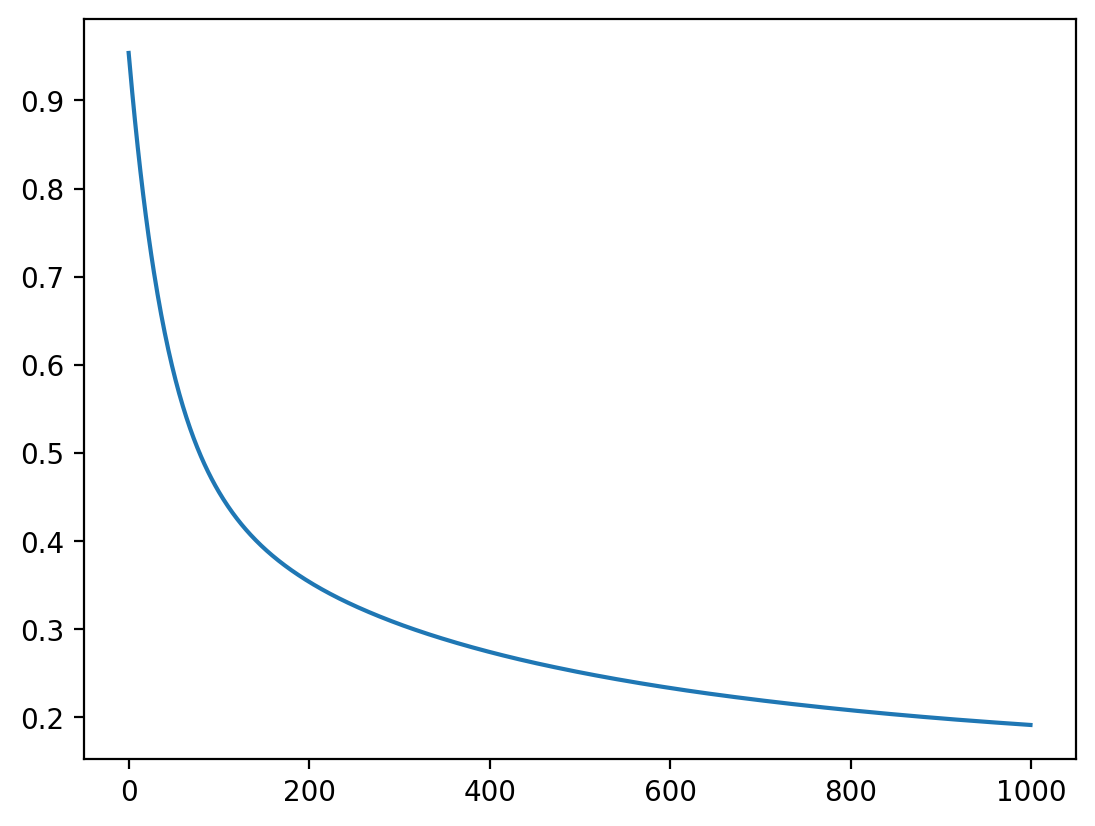

In [54]:
plt.plot(range(epochs), losses)

In [55]:
# Now it's time to evaluate the model on the test data
with torch.no_grad(): #turn off back propagation
    y_eval = model.forward(X_test) 
    loss = criterion(y_eval, y_test)

In [56]:
loss

tensor(0.1972)

In [57]:
correct = 0 
tot = 0
with torch.no_grad():
    for i , data in enumerate(X_test):
        y_val = model.forward(data)
        
        print(f'{i+1}.) {str(y_val)} \t {y_test[i]} \t {y_val.argmax().item()}') 
        tot +=1
        if y_val.argmax().item() == y_test[i]:
            correct +=1

1.) tensor([ 2.4521, -2.9571]) 	 0 	 0
2.) tensor([ 3.0434, -3.6627]) 	 0 	 0
3.) tensor([ 1.7400, -2.3222]) 	 0 	 0
4.) tensor([ 0.4902, -0.7207]) 	 0 	 0
5.) tensor([-0.0252, -0.2577]) 	 1 	 0
6.) tensor([-0.4890, -0.0402]) 	 1 	 1
7.) tensor([ 0.1986, -1.1363]) 	 0 	 0
8.) tensor([ 2.7269, -3.2047]) 	 0 	 0
9.) tensor([-0.2372, -0.3937]) 	 0 	 0
10.) tensor([ 2.5906, -3.8641]) 	 0 	 0
11.) tensor([ 2.1116, -3.1448]) 	 0 	 0
12.) tensor([ 1.2928, -1.3578]) 	 0 	 0
13.) tensor([ 0.8967, -1.0149]) 	 1 	 0
14.) tensor([-0.3307, -0.1168]) 	 1 	 1
15.) tensor([ 1.1979, -1.7372]) 	 0 	 0
16.) tensor([ 2.8892, -2.7715]) 	 0 	 0
17.) tensor([ 2.4852, -2.5225]) 	 0 	 0
18.) tensor([ 2.3160, -2.5250]) 	 0 	 0
19.) tensor([ 0.0307, -0.4751]) 	 0 	 0
20.) tensor([ 1.5516, -2.0311]) 	 0 	 0
21.) tensor([ 1.9216, -2.8634]) 	 0 	 0
22.) tensor([ 2.8419, -4.0654]) 	 0 	 0
23.) tensor([ 0.1910, -0.9745]) 	 0 	 0
24.) tensor([ 2.6140, -3.7907]) 	 0 	 0
25.) tensor([ 2.2825, -2.4487]) 	 0 	 0
26.) tens

471.) tensor([-0.0235, -0.3303]) 	 0 	 0
472.) tensor([ 1.3484, -2.1646]) 	 0 	 0
473.) tensor([ 0.5069, -0.8551]) 	 1 	 0
474.) tensor([ 1.4464, -2.2488]) 	 0 	 0
475.) tensor([ 2.4410, -2.9846]) 	 0 	 0
476.) tensor([-0.8483,  0.2744]) 	 1 	 1
477.) tensor([ 2.0791, -2.4648]) 	 0 	 0
478.) tensor([ 0.7213, -0.9270]) 	 0 	 0
479.) tensor([ 0.1464, -0.4534]) 	 0 	 0
480.) tensor([ 1.2425, -1.2550]) 	 0 	 0
481.) tensor([-0.0547, -0.2381]) 	 0 	 0
482.) tensor([ 2.5216, -3.4576]) 	 0 	 0
483.) tensor([ 0.0574, -0.6960]) 	 0 	 0
484.) tensor([ 1.0941, -1.2887]) 	 0 	 0
485.) tensor([ 0.9364, -1.3489]) 	 0 	 0
486.) tensor([ 1.4492, -1.3907]) 	 0 	 0
487.) tensor([ 2.0241, -2.1233]) 	 0 	 0
488.) tensor([ 0.7200, -1.2409]) 	 0 	 0
489.) tensor([ 3.1000, -3.6576]) 	 0 	 0
490.) tensor([ 0.3061, -0.4939]) 	 1 	 0
491.) tensor([ 0.4948, -0.7017]) 	 0 	 0
492.) tensor([-0.5961,  0.1399]) 	 1 	 1
493.) tensor([ 0.7109, -0.9339]) 	 0 	 0
494.) tensor([ 1.5751, -1.5617]) 	 0 	 0
495.) tensor([ 1

In [58]:
print(f'we got {correct} correct') 

we got 750 correct


In [59]:
precision = correct / tot
precision *100

93.75